# Perception Stack - Notebook 02a: Object Tracking via SAM 2

This notebook runs Stage 1 and Stage 2 of the Perception Stack pipeline.
Objects are first detected using the CLEVRER Mask R-CNN proposal files, which
provide pixel-accurate centroids at high confidence. SAM 2 is then prompted
with these centroids and propagates object masks across all 128 frames of each clip.
Derived quantities (centroids, areas, entry/exit frames, mask overlap pairs) are
saved as compressed `.npz` files to Drive.

## Steps
- Mount Google Drive and define all constants and paths
- Install dependencies (SAM 2 from GitHub, supervision, pycocotools)
- Load annotation files and define object first-visible-frame utilities
- Attempt YOLO-based detection (retained for documentation; rejected due to domain gap)
- Visualize YOLO failure cases and save figures
- Load CLEVRER proposal files and decode RLE masks to extract object centroids
- Download SAM 2 base+ checkpoint and initialize the video predictor
- Run SAM 2 inference on all 70 clips: extract all frames, prompt with proposal
  centroids, propagate masks forward and backward
- Compute derived quantities: centroid trajectories, object areas, entry and exit
  frames, and mask overlap pairs with pixel counts
- Save derived quantities as compressed `.npz` to Drive (raw masks are not saved
  due to storage constraints)
- Generate trajectory and overlap visualization figures for the first 3 clips
- Report final Drive storage usage

---
> **Note:** This notebook is natively developed and run on Google Colab (A100 GPU required).
> If it does not render correctly in your viewer, please open it directly on Colab:
> [Open in Google Colab](<https://colab.research.google.com/drive/159JYZgDWzct4JomrahlQ0ZOXWVvYGUxV?usp=sharing>)

---
## Cell 1 - Mount Drive + Constants + Paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── CLEAR: Delete all NB02a outputs ────────────────────────────────────────
import os, shutil

BASE = "/content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project"

# Clear SAM2 npz files
sam2_dir = os.path.join(BASE, "outputs/stage1_sam2")
deleted = 0
for f in os.listdir(sam2_dir):
    if f.startswith("stage1_sam2_") and f.endswith(".npz"):
        os.remove(os.path.join(sam2_dir, f))
        deleted += 1
print(f"Deleted {deleted} SAM2 npz files")

# Clear NB02a figures
fig_dir = os.path.join(BASE, "figures")
deleted_figs = 0
for f in os.listdir(fig_dir):
    if f.startswith("02a_"):
        os.remove(os.path.join(fig_dir, f))
        deleted_figs += 1
print(f"Deleted {deleted_figs} NB02a figures")

print("NB02a slate cleared.")

Deleted 2 SAM2 npz files
Deleted 31 NB02a figures
NB02a slate cleared.


In [3]:
# ── Cell 1 — Mount Drive + Constants + Paths ───────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
import json

# ── Constants ──────────────────────────────────────────────────────────────
NO_CLIPS  = 70      # change this one number to scale up
SEED      = 42

# ── Base path on Drive ─────────────────────────────────────────────────────
BASE          = "/content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project"
CLIPS_DIR     = os.path.join(BASE, "data/clips")
ANN_DIR       = os.path.join(BASE, "data/annotations")
ID_PATH       = os.path.join(BASE, "data/selected_clip_ids.json")
OUT_SAM2      = os.path.join(BASE, "outputs/stage1_sam2")
FIGURES_DIR   = os.path.join(BASE, "figures")

os.makedirs(OUT_SAM2, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Load selected clip IDs ─────────────────────────────────────────────────
with open(ID_PATH, 'r') as f:
    ALL_SELECTED_IDS = json.load(f)

SELECTED_IDS = ALL_SELECTED_IDS[:NO_CLIPS]
print(f"Drive mounted.")
print(f"Working with {NO_CLIPS} clips: {SELECTED_IDS}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.
Working with 70 clips: [10001, 10002, 10003, 10004, 10005, 10006, 10007, 10008, 10009, 10010, 10011, 10012, 10013, 10014, 10015, 10016, 10017, 10018, 10019, 10020, 10021, 10022, 10023, 10024, 10025, 10026, 10027, 10028, 10029, 10030, 10031, 10032, 10033, 10034, 10035, 10036, 10037, 10038, 10039, 10040, 10041, 10042, 10043, 10044, 10045, 10046, 10047, 10048, 10049, 10050, 10051, 10052, 10053, 10054, 10055, 10056, 10057, 10058, 10059, 10060, 10061, 10062, 10063, 10064, 10065, 10066, 10067, 10068, 10069, 10070]


---
## Cell 2 — Install Dependencies

In [4]:
# ── Cell 2 — Install Dependencies ─────────────────────────────────────────

# ultralytics: YOLOv8 for object detection + point prompt generation
# SAM 2: video object segmentation and tracking (Meta)
# supervision: helper utilities for bounding box handling

!pip install -q ultralytics
!pip install -q supervision
!pip install -q "git+https://github.com/facebookresearch/sam2.git"

print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 12.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 11.5 MB/s eta 0:00:00
Dependencies installed.


---
## Cell 3 — Load Annotations + Identify First Visible Frame Per Object

In [6]:
# ── Cell 3 — Load Annotations + Identify First Visible Frame Per Object ────
import json
import os

def load_annotation(vid_id):
    """Load annotation JSON for a given clip ID."""
    ann_path = os.path.join(ANN_DIR, f"annotation_{vid_id}.json")
    with open(ann_path, 'r') as f:
        return json.load(f)

def get_object_first_visible_frame(annotation):
    """
    For each object, find the first frame where inside_camera_view is True.
    Returns dict: {object_id -> first_visible_frame_id}
    If object is visible from frame 0, first_visible_frame_id = 0.
    If object never appears, it is excluded.
    """
    first_visible = {}
    for frame_entry in annotation['motion_trajectory']:
        frame_id = frame_entry['frame_id']
        for obj in frame_entry['objects']:
            obj_id = obj['object_id']
            if obj_id not in first_visible and obj['inside_camera_view']:
                first_visible[obj_id] = frame_id
    return first_visible

def get_object_properties(annotation):
    """
    Returns dict: {object_id -> {color, material, shape}}
    """
    return {
        obj['object_id']: {
            'color'    : obj['color'],
            'material' : obj['material'],
            'shape'    : obj['shape']
        }
        for obj in annotation['object_property']
    }

# ── Verify for all selected clips ──────────────────────────────────────────
for vid_id in SELECTED_IDS[:2]:
    ann        = load_annotation(vid_id)
    first_vis  = get_object_first_visible_frame(ann)
    obj_props  = get_object_properties(ann)

    print(f"\nClip {vid_id}:")
    for obj_id, props in obj_props.items():
        fv = first_vis.get(obj_id, 'never')
        print(f"  Object {obj_id}: {props['color']} {props['material']} "
              f"{props['shape']} -- first visible frame: {fv}")

print("\nCell 3 complete.")


Clip 10001:
  Object 0: yellow rubber sphere -- first visible frame: 14
  Object 1: green metal sphere -- first visible frame: 0
  Object 2: yellow metal cylinder -- first visible frame: 0
  Object 3: gray metal cube -- first visible frame: 0
  Object 4: brown metal cube -- first visible frame: 0

Clip 10002:
  Object 0: green metal cube -- first visible frame: 20
  Object 1: gray metal sphere -- first visible frame: 19
  Object 2: blue metal cylinder -- first visible frame: 0
  Object 3: gray rubber sphere -- first visible frame: 69
  Object 4: brown metal cylinder -- first visible frame: 0
  Object 5: cyan rubber cube -- first visible frame: 0

Cell 3 complete.


---
# Cell 4 - YOLO

# **YOLO Detection Results -- Summary**
- YOLOv8 (medium and large variants) was evaluated for object detection on
- CLEVRER clips with confidence thresholds of 0.1 and 0.25, and iou=0.3.

# Results were consistently poor:
- Cubes: 0 detections across all frames and both clips
- Cylinders: occasionally detected as 'cup' or 'orange'
- Spheres: partially detected as 'sports ball', often missed
- Multiple variants tried: yolov8m, yolov8l, conf=0.25, conf=0.1, iou=0.3

# Root cause:
- CLEVRER objects are synthetic, shiny, and geometric -- fundamentally out of distribution for COCO-trained YOLO models.
- Increasing model size made results worse, not better.

# Conclusion:
- YOLO is not suitable as a point prompt generator for CLEVRER. Moving to HSV color segmentation as primary detection method.

---

# **Why HSV Segmentation Was Not Used**

- HSV color segmentation was considered as a fallback after YOLO failure.
- While viable for CLEVRER's controlled environment, it introduces failure  cases: shadows altering HSV values, partial occlusion corrupting color blobs, and objects in close proximity with similar hues causing centroid drift.
- These failure modes would propagate directly into SAM 2 point prompts, compromising mask quality downstream.
- We instead use precomputed Mask R-CNN proposals from the CLEVRER authors (derender_proposals), which provide pixel-accurate per-object masks at 0.999+ confidence across all frames, giving us reliable point prompts with zero detection failures.

---

In [7]:
PROPOSALS_DIR = os.path.join(BASE, "data/proposals")

In [8]:
# ── Cell 4 (revised) — Load Proposal Centroids + Visualize ────────────────
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pycocotools import mask as mask_utils

PROPOSALS_DIR = os.path.join(BASE, "data/proposals")

def load_proposal(vid_id):
    """Load proposal JSON for a given clip ID."""
    prop_path = os.path.join(PROPOSALS_DIR, f"proposal_{vid_id}.json")
    with open(prop_path, 'r') as f:
        return json.load(f)

def decode_mask(rle):
    """Decode RLE mask to binary numpy array."""
    return mask_utils.decode(rle).astype(bool)

def get_centroid(binary_mask):
    """Compute centroid (cx, cy) from binary mask."""
    ys, xs = np.where(binary_mask)
    if len(xs) == 0:
        return None
    return float(np.mean(xs)), float(np.mean(ys))

def get_proposal_centroids(proposal, first_vis):
    """
    For each object, get centroid from its first visible frame
    using the proposal file masks.
    Returns dict: {(color, material, shape) -> (cx, cy, frame_id)}
    """
    centroids = {}
    # Build lookup: frame_id -> objects list
    frames_lookup = {f['frame_index']: f['objects']
                     for f in proposal['frames']}

    for obj_id, first_frame in first_vis.items():
        # Use first_visible_frame + 10 for better detection
        target_frame = min(first_frame + 15, 127)
        objects_in_frame = frames_lookup.get(target_frame, [])

        for obj in objects_in_frame:
            binary_mask = decode_mask(obj['mask'])
            centroid    = get_centroid(binary_mask)
            if centroid is None:
                continue
            key = (obj['color'], obj['material'], obj['shape'])
            if key not in centroids:
                centroids[key] = {
                    'cx'       : centroid[0],
                    'cy'       : centroid[1],
                    'frame_id' : target_frame,
                    'color'    : obj['color'],
                    'material' : obj['material'],
                    'shape'    : obj['shape']
                }
    return centroids

In [10]:
def extract_frame(clip_path, frame_id):
    """Extract a single frame from an mp4 file."""
    cap = cv2.VideoCapture(clip_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise ValueError(f"Could not read frame {frame_id} from {clip_path}")
    return frame  # BGR format


Clip 10001 -- detected 5 objects:
  brown metal cube -> centroid (338.4, 143.1) at frame 15
  gray metal cube -> centroid (50.6, 38.0) at frame 15
  green metal sphere -> centroid (166.7, 102.1) at frame 15
  yellow rubber sphere -> centroid (3.1, 127.1) at frame 15
  yellow metal cylinder -> centroid (325.0, 84.5) at frame 15


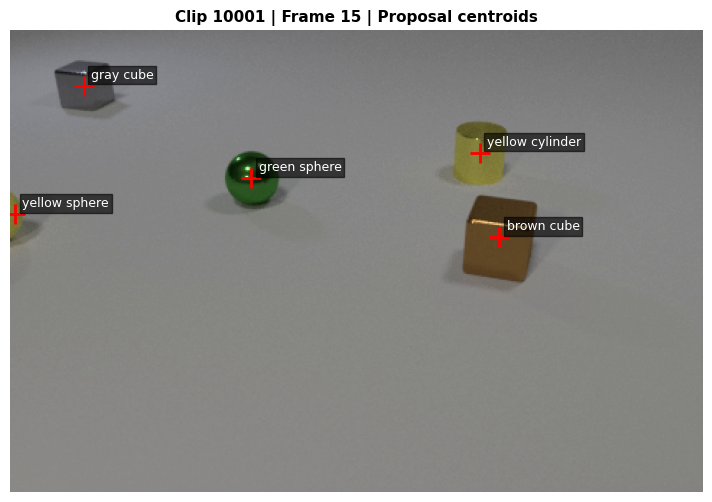

  Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/02a_proposals_clip10001_frame15.jpg

Clip 10002 -- detected 6 objects:
  blue metal cylinder -> centroid (187.2, 86.7) at frame 15
  brown metal cylinder -> centroid (415.3, 152.5) at frame 15
  cyan rubber cube -> centroid (143.2, 120.5) at frame 15
  gray metal sphere -> centroid (286.2, 237.7) at frame 34
  green metal cube -> centroid (89.5, 188.8) at frame 34
  gray rubber sphere -> centroid (416.2, 79.6) at frame 84


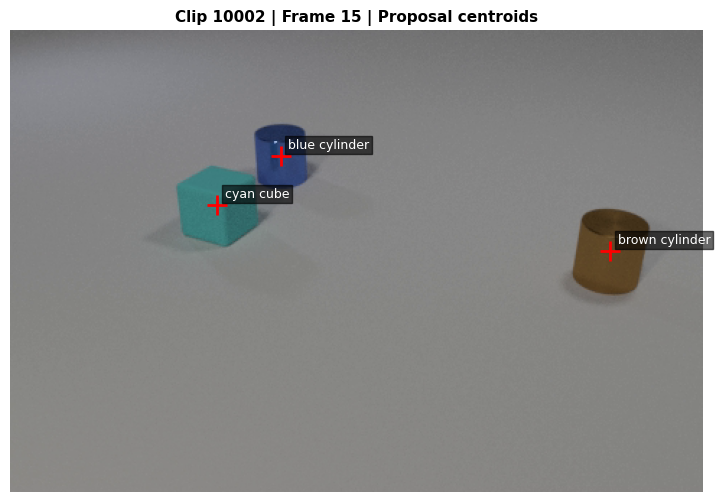

  Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/02a_proposals_clip10002_frame15.jpg


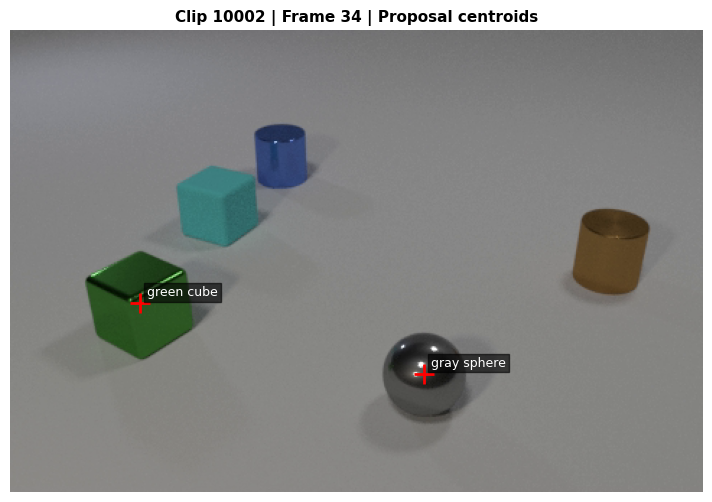

  Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/02a_proposals_clip10002_frame34.jpg


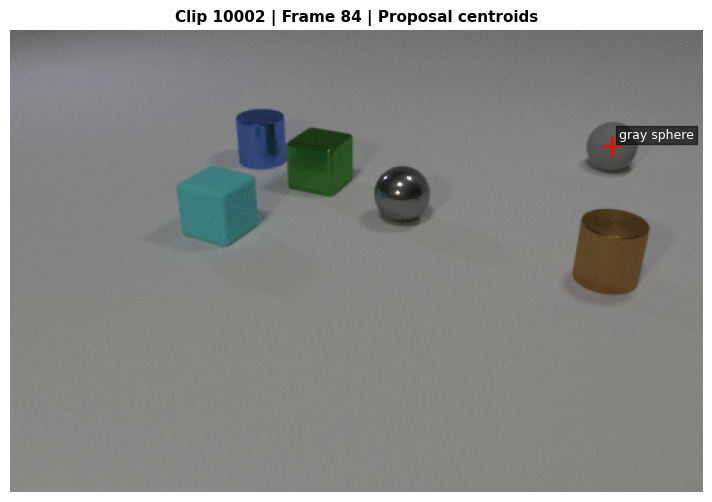

  Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/02a_proposals_clip10002_frame84.jpg

Cell 4 complete.


In [11]:
# ── Run for clips + visualize ────────────────────────────────────────
for vid_id in SELECTED_IDS[:2]:
    clip_path = os.path.join(CLIPS_DIR, f"video_{vid_id:05d}.mp4")
    ann       = load_annotation(vid_id)
    first_vis = get_object_first_visible_frame(ann)
    proposal  = load_proposal(vid_id)
    centroids = get_proposal_centroids(proposal, first_vis)

    print(f"\nClip {vid_id} -- detected {len(centroids)} objects:")
    for key, c in centroids.items():
        print(f"  {c['color']} {c['material']} {c['shape']} "
              f"-> centroid ({c['cx']:.1f}, {c['cy']:.1f}) "
              f"at frame {c['frame_id']}")

    # ── Visualize centroids on frame ───────────────────────────────────────
    # Group by frame_id
    frames_to_show = sorted(set(c['frame_id'] for c in centroids.values()))

    for frame_id in frames_to_show:
        frame_bgr = extract_frame(clip_path, frame_id)
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.imshow(frame_rgb)

        for key, c in centroids.items():
            if c['frame_id'] != frame_id:
                continue
            ax.plot(c['cx'], c['cy'], 'r+',
                    markersize=15, markeredgewidth=2)
            ax.text(c['cx'] + 5, c['cy'] - 5,
                    f"{c['color']} {c['shape']}",
                    color='white', fontsize=9,
                    bbox=dict(facecolor='black', alpha=0.6, pad=2))

        ax.set_title(f"Clip {vid_id} | Frame {frame_id} | "
                     f"Proposal centroids", fontsize=11, fontweight='bold')
        ax.axis('off')

        fig_path = os.path.join(FIGURES_DIR,
                    f"02a_proposals_clip{vid_id}_frame{frame_id}.jpg")
        plt.savefig(fig_path, dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"  Saved -> {fig_path}")

print("\nCell 4 complete.")

---
## Cell 5 - SAM!

In [12]:
# ── Cell 5 — Load SAM 2 ────────────────────────────────────────────────────
import torch
from sam2.build_sam import build_sam2_video_predictor

# ── Download SAM 2 base+ checkpoint ───────────────────────────────────────
import os
SAM2_CHECKPOINT = "/content/sam2_hiera_base_plus.pt"
SAM2_CONFIG     = "sam2_hiera_b+.yaml"

if not os.path.exists(SAM2_CHECKPOINT):
    print("Downloading SAM 2 base+ checkpoint...")
    !wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_base_plus.pt \
        -O {SAM2_CHECKPOINT}
    print("Downloaded.")
else:
    print("Checkpoint already exists, skipping download.")

# ── Load predictor ─────────────────────────────────────────────────────────
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
predictor = build_sam2_video_predictor(SAM2_CONFIG, SAM2_CHECKPOINT,
                                        device=device)

print(f"SAM 2 loaded on: {device}")
print(f"VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Downloaded.
SAM 2 loaded on: cuda
VRAM used: 0.47 GB


---
## Cell 6 - SAM2 inference


Processing clip 10001...
  Extracting frames...
  128 frames extracted.
  Running SAM 2...


frame loading (JPEG): 100%|██████████| 128/128 [00:02<00:00, 43.64it/s]
/usr/local/lib/python3.12/dist-packages/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/usr/local/lib/python3.12/dist-packages/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 113/113 [00:11<00:00,  9.50it/s]


  SAM 2 complete. 5 objects tracked.


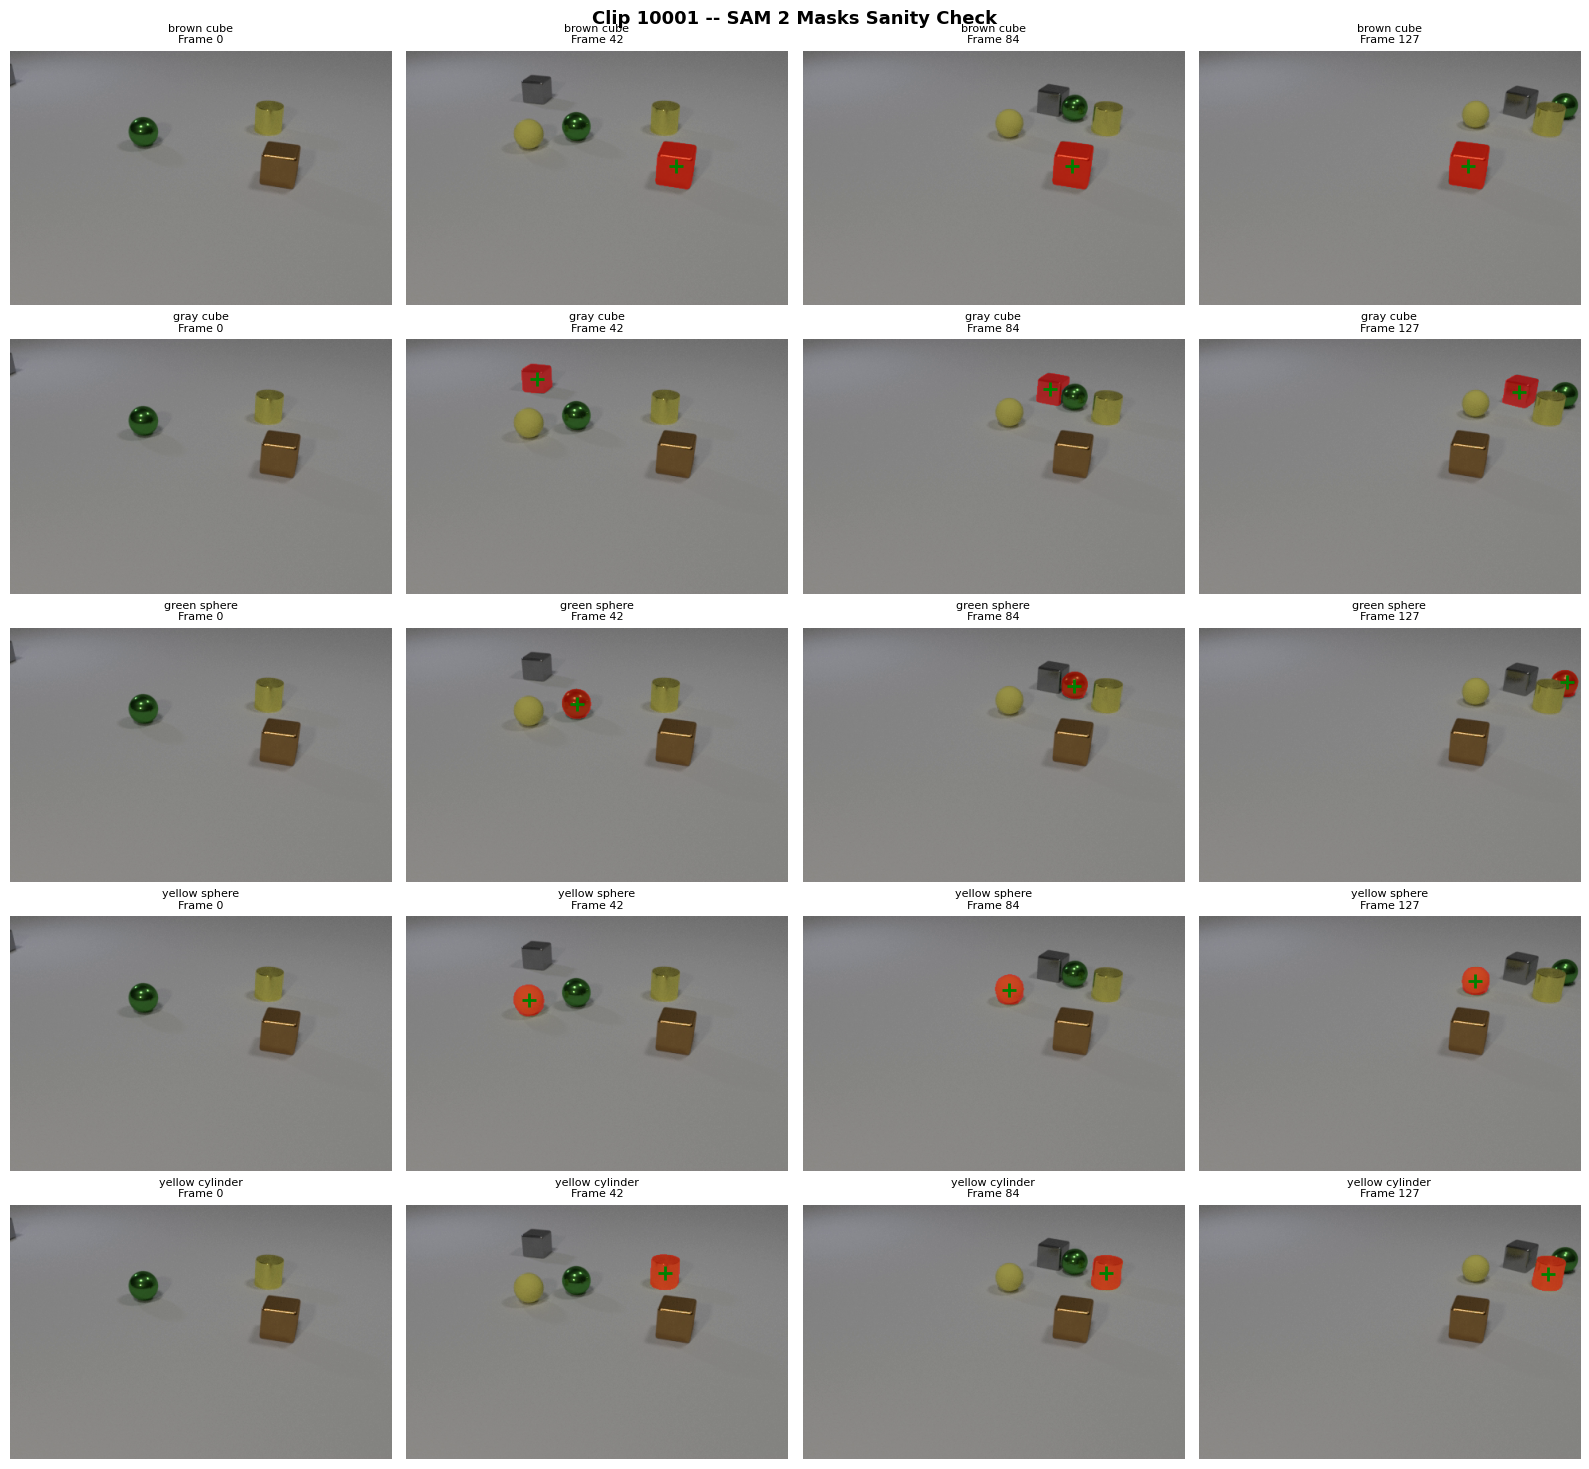

  Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/02a_sam2_masks_clip10001.jpg

Processing clip 10002...
  Extracting frames...
  128 frames extracted.
  Running SAM 2...


frame loading (JPEG): 100%|██████████| 128/128 [00:03<00:00, 42.04it/s]
/usr/local/lib/python3.12/dist-packages/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/usr/local/lib/python3.12/dist-packages/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 113/113 [00:14<00:00,  8.06it/s]


  SAM 2 complete. 6 objects tracked.


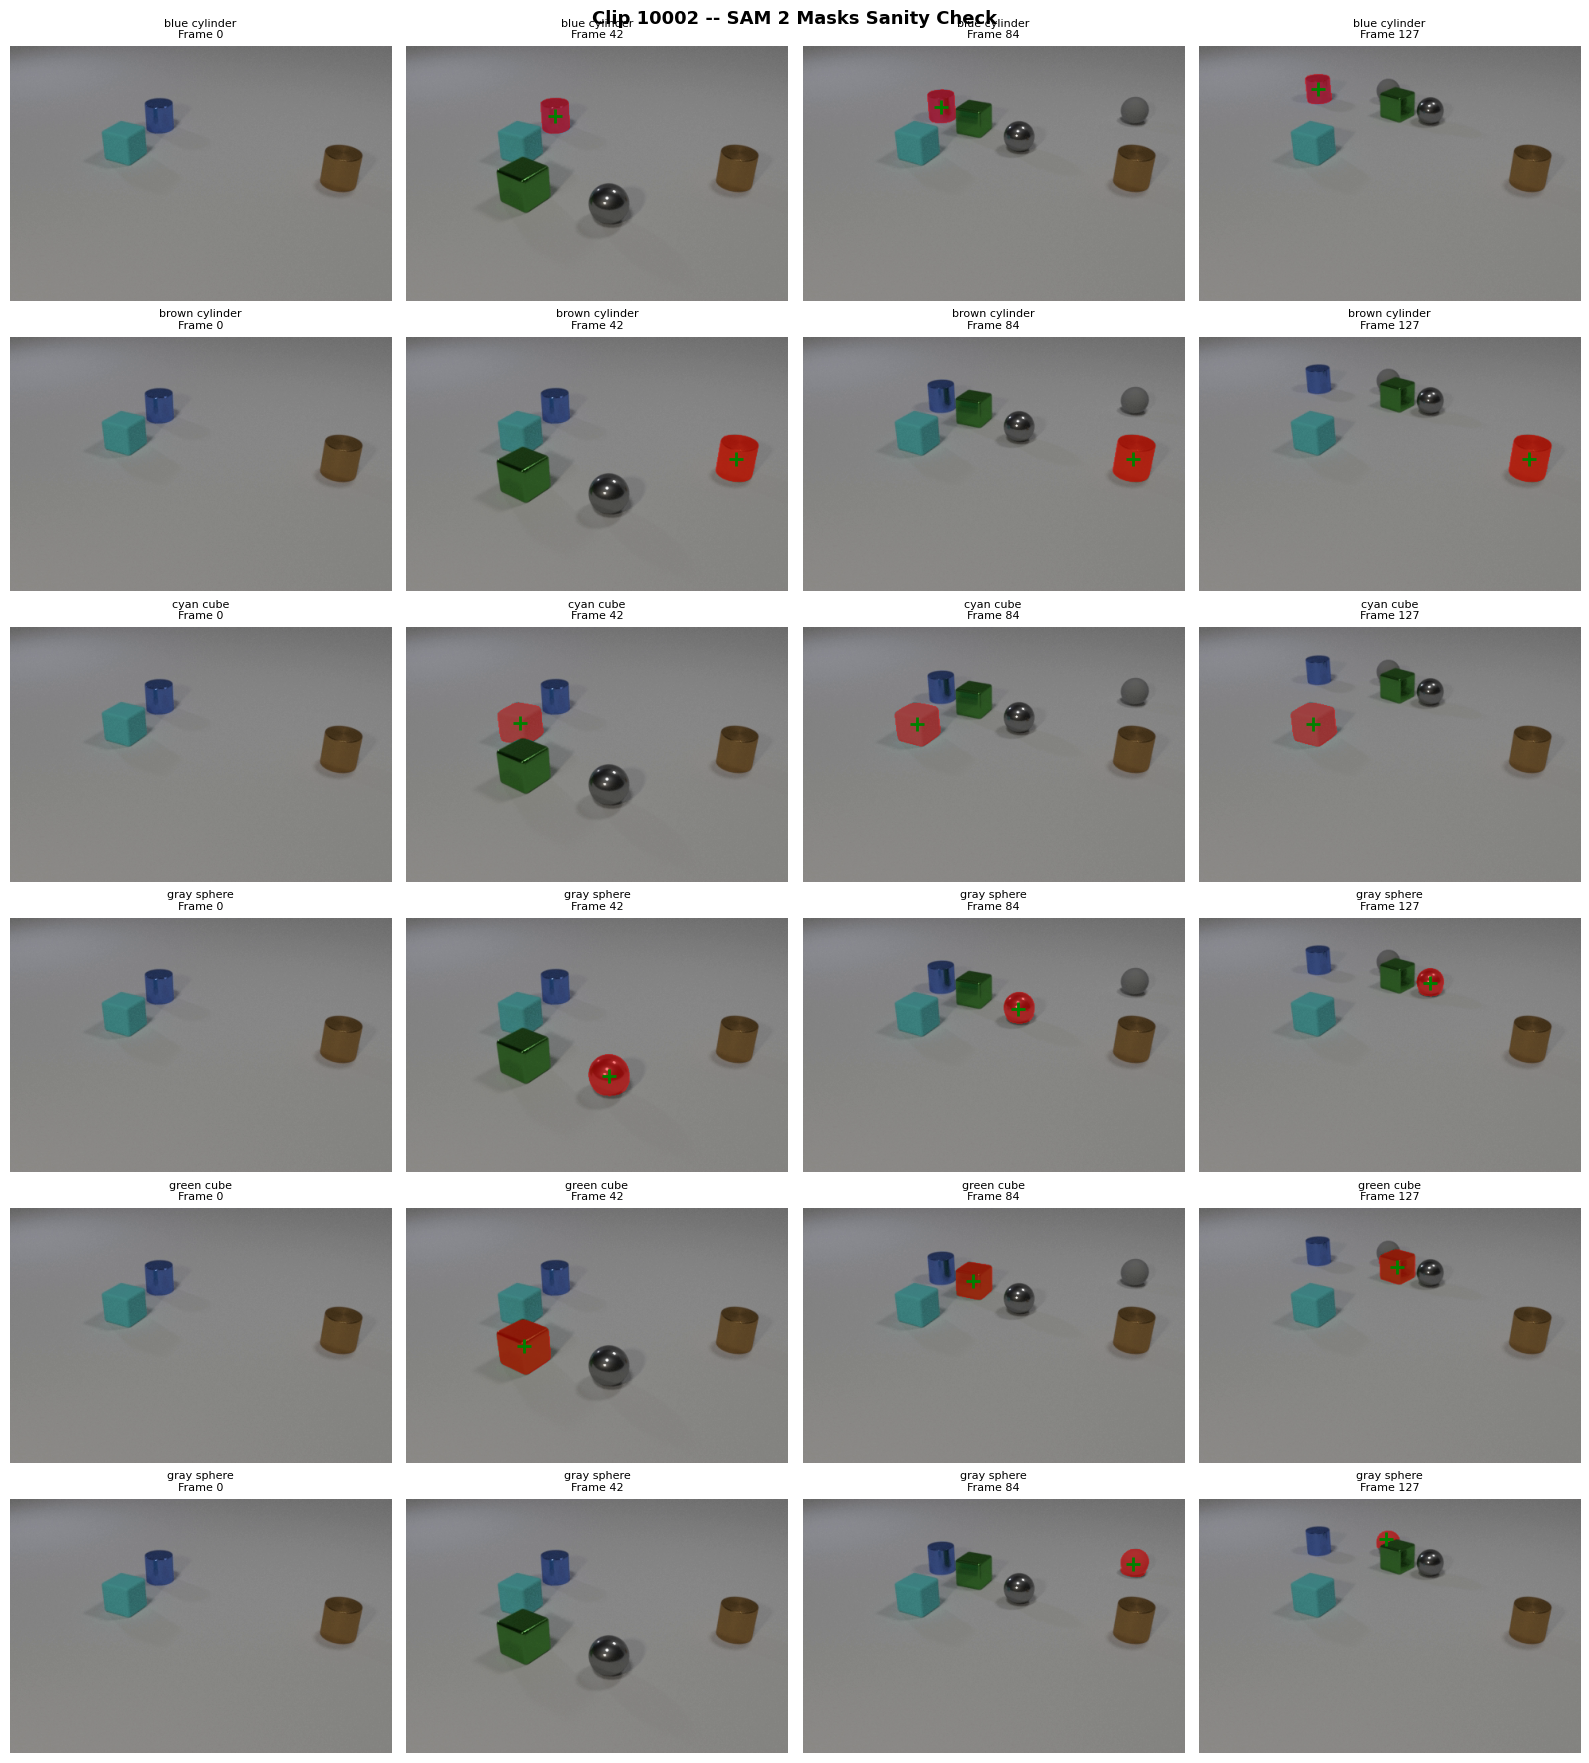

  Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/02a_sam2_masks_clip10002.jpg

Processing clip 10003...
  Extracting frames...
  128 frames extracted.
  Running SAM 2...


frame loading (JPEG): 100%|██████████| 128/128 [00:03<00:00, 41.03it/s]
/usr/local/lib/python3.12/dist-packages/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/usr/local/lib/python3.12/dist-packages/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 113/113 [00:09<00:00, 11.51it/s]


  SAM 2 complete. 4 objects tracked.

Processing clip 10004...
  Extracting frames...
  128 frames extracted.
  Running SAM 2...


propagate in video: 100%|██████████| 113/113 [00:09<00:00, 11.35it/s]


  SAM 2 complete. 4 objects tracked.

Processing clip 10005...
  Extracting frames...
  128 frames extracted.
  Running SAM 2...


...

  SAM 2 complete. 6 objects tracked.

Processing clip 10069...
  Extracting frames...
  128 frames extracted.
  Running SAM 2...


propagate in video: 100%|██████████| 113/113 [00:09<00:00, 11.56it/s]


  SAM 2 complete. 4 objects tracked.

Processing clip 10070...
  Extracting frames...
  128 frames extracted.
  Running SAM 2...


propagate in video: 100%|██████████| 113/113 [00:11<00:00,  9.52it/s]


  SAM 2 complete. 5 objects tracked.

Cell 6 complete.


In [17]:
# ── Cell 6 — SAM 2 Inference + Sanity Check Visualization ─────────────────
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import tempfile, shutil, os

def extract_all_frames(clip_path):
    """Extract all frames from mp4. Returns list of RGB numpy arrays."""
    cap    = cv2.VideoCapture(clip_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames

def run_sam2_on_clip(predictor, frames_rgb, centroids):
    """
    Run SAM 2 on a clip.
    frames_rgb : list of 128 RGB numpy arrays
    centroids  : dict from get_proposal_centroids()
    Returns dict: {obj_key -> (128, H, W) bool mask array}
    """
    # ── Write frames to temp directory (SAM 2 needs files on disk) ────────
    tmp_dir = tempfile.mkdtemp()
    try:
        for i, frame in enumerate(frames_rgb):
            frame_path = os.path.join(tmp_dir, f"{i:05d}.jpg")
            Image.fromarray(frame).save(frame_path)

        # ── Initialize predictor with video ───────────────────────────────
        with torch.inference_mode(), torch.autocast("cuda", dtype=torch.float16):
            inference_state = predictor.init_state(video_path=tmp_dir)
            predictor.reset_state(inference_state)

            # ── Add point prompts per object ───────────────────────────────
            obj_keys  = list(centroids.keys())
            obj_id_map = {}  # SAM obj_id (int) -> obj_key

            for sam_obj_id, obj_key in enumerate(obj_keys):
                c          = centroids[obj_key]
                point      = np.array([[c['cx'], c['cy']]], dtype=np.float32)
                label      = np.array([1], dtype=np.int32)  # 1 = foreground
                frame_idx  = c['frame_id']
                obj_id_map[sam_obj_id] = obj_key

                predictor.add_new_points_or_box(
                    inference_state = inference_state,
                    frame_idx       = frame_idx,
                    obj_id          = sam_obj_id,
                    points          = point,
                    labels          = label
                )

            # ── Propagate across all frames ────────────────────────────────
            # all_masks[obj_key][frame_id] = (H, W) bool mask
            all_masks = {key: {} for key in obj_keys}

            for frame_idx, obj_ids, masks in predictor.propagate_in_video(
                    inference_state):
                for obj_id, mask in zip(obj_ids, masks):
                    obj_key = obj_id_map[int(obj_id)]
                    # mask shape: (1, H, W) -- squeeze to (H, W)
                    all_masks[obj_key][frame_idx] = mask[0].cpu().numpy() > 0.0

    finally:
        shutil.rmtree(tmp_dir)  # always clean up temp dir

    # ── Convert to numpy arrays (128, H, W) ───────────────────────────────
    n_frames = len(frames_rgb)
    result   = {}
    for obj_key, frame_masks in all_masks.items():
        arr = np.zeros((n_frames, frames_rgb[0].shape[0],
                        frames_rgb[0].shape[1]), dtype=bool)
        for fid, m in frame_masks.items():
            arr[fid] = m
        result[obj_key] = arr

    return result

# ── Run SAM 2 + visualize for both clips ──────────────────────────────────
sam2_results = {}  # vid_id -> {obj_key -> (128, H, W) bool array}

for vid_id in SELECTED_IDS:
    print(f"\nProcessing clip {vid_id}...")
    clip_path  = os.path.join(CLIPS_DIR, f"video_{vid_id:05d}.mp4")
    ann        = load_annotation(vid_id)
    first_vis  = get_object_first_visible_frame(ann)
    proposal   = load_proposal(vid_id)
    centroids  = get_proposal_centroids(proposal, first_vis)

    # ── Extract all frames ─────────────────────────────────────────────────
    print(f"  Extracting frames...")
    frames_rgb = extract_all_frames(clip_path)
    print(f"  {len(frames_rgb)} frames extracted.")

    # ── Run SAM 2 ──────────────────────────────────────────────────────────
    print(f"  Running SAM 2...")
    masks = run_sam2_on_clip(predictor, frames_rgb, centroids)
    sam2_results[vid_id] = masks
    print(f"  SAM 2 complete. {len(masks)} objects tracked.")

    # ── Sanity check visualization ─────────────────────────────────────────
    # Show masks at 4 evenly spaced frames: 0, 42, 84, 127
    # for only 2 clips
    if vid_id in SELECTED_IDS[:2]:
      check_frames = [0, 42, 84, 127]
      obj_keys     = list(masks.keys())
      n_objs       = len(obj_keys)

      fig, axes = plt.subplots(n_objs, len(check_frames),
                                figsize=(16, 3 * n_objs))
      if n_objs == 1:
          axes = axes[np.newaxis, :]

      fig.suptitle(f"Clip {vid_id} -- SAM 2 Masks Sanity Check",
                  fontsize=13, fontweight='bold')

      for row, obj_key in enumerate(obj_keys):
          color, material, shape = obj_key
          for col, fid in enumerate(check_frames):
              ax   = axes[row][col]
              frame = frames_rgb[fid]
              mask  = masks[obj_key][fid]

              # Overlay mask in red
              overlay        = frame.copy()
              overlay[mask]  = (overlay[mask] * 0.5 +
                                np.array([255, 0, 0]) * 0.5).astype(np.uint8)

              # Compute and draw centroid
              if mask.any():
                  ys, xs = np.where(mask)
                  cx, cy = float(np.mean(xs)), float(np.mean(ys))
                  ax.plot(cx, cy, 'g+', markersize=10, markeredgewidth=2)

              ax.imshow(overlay)
              ax.set_title(f"{color} {shape}\nFrame {fid}", fontsize=8)
              ax.axis('off')

      plt.tight_layout()
      fig_path = os.path.join(FIGURES_DIR, f"02a_sam2_masks_clip{vid_id}.jpg")
      plt.savefig(fig_path, dpi=120, bbox_inches='tight')
      plt.show()
      plt.close()
      print(f"  Saved -> {fig_path}")

print("\nCell 6 complete.")

---
## Cell 7 - Compute Derived Quantities + Save to Drive

In [18]:
# ── Cell 7 — Compute Derived Quantities + Save to Drive ───────────────────
import numpy as np
import os

def compute_centroids_per_frame(mask_array):
    n_frames  = mask_array.shape[0]
    centroids = np.full((n_frames, 2), np.nan)
    for fid in range(n_frames):
        mask = mask_array[fid]
        if mask.any():
            ys, xs         = np.where(mask)
            centroids[fid] = [float(np.mean(xs)), float(np.mean(ys))]
    return centroids

def compute_areas_per_frame(mask_array):
    return mask_array.sum(axis=(1, 2))

def compute_overlap_pairs(masks_dict):
    obj_keys = list(masks_dict.keys())
    overlaps = []
    for i in range(len(obj_keys)):
        for j in range(i + 1, len(obj_keys)):
            key_a  = obj_keys[i]
            key_b  = obj_keys[j]
            mask_a = masks_dict[key_a]
            mask_b = masks_dict[key_b]
            for fid in range(mask_a.shape[0]):
                intersection = mask_a[fid] & mask_b[fid]
                if intersection.any():
                    overlaps.append({
                        'obj_a'               : key_a,
                        'obj_b'               : key_b,
                        'first_overlap_frame' : fid,
                        'overlap_pixel_count' : int(intersection.sum())
                    })
                    break
    return overlaps

def compute_entry_exit_frames(areas):
    entry_frame = None
    exit_frame  = None
    for fid in range(1, len(areas)):
        if areas[fid - 1] == 0 and areas[fid] > 0:
            entry_frame = fid
        if areas[fid - 1] > 0 and areas[fid] == 0:
            exit_frame  = fid
    return {'entry_frame': entry_frame, 'exit_frame': exit_frame}

def save_clip_npz(vid_id, masks_dict, out_dir):
    """
    Compute all derived quantities and save as .npz to Drive.
    One file per clip: stage1_sam2_{vid_id:05d}.npz
    """
    save_dict = {}

    # ── Per object quantities ──────────────────────────────────────────────
    obj_keys  = list(masks_dict.keys())
    obj_labels = []  # list of "color_material_shape" strings

    for obj_key in obj_keys:
        color, material, shape = obj_key
        label      = f"{color}_{material}_{shape}"
        mask_array = masks_dict[obj_key]

        centroids  = compute_centroids_per_frame(mask_array)
        areas      = compute_areas_per_frame(mask_array)
        entry_exit = compute_entry_exit_frames(areas)

        # Save with label as key prefix
        save_dict[f"{label}__centroids"]    = centroids
        save_dict[f"{label}__areas"]        = areas
        save_dict[f"{label}__entry_frame"]  = np.array(
            [entry_exit['entry_frame'] if entry_exit['entry_frame']
             is not None else -1])
        save_dict[f"{label}__exit_frame"]   = np.array(
            [entry_exit['exit_frame'] if entry_exit['exit_frame']
             is not None else -1])

        obj_labels.append(label)

    # ── Overlap pairs ──────────────────────────────────────────────────────
    overlaps        = compute_overlap_pairs(masks_dict)
    overlap_obj_a   = []
    overlap_obj_b   = []
    overlap_frames  = []
    overlap_pixels  = []

    for ov in overlaps:
        a = ov['obj_a']
        b = ov['obj_b']
        overlap_obj_a.append(f"{a[0]}_{a[1]}_{a[2]}")
        overlap_obj_b.append(f"{b[0]}_{b[1]}_{b[2]}")
        overlap_frames.append(ov['first_overlap_frame'])
        overlap_pixels.append(ov['overlap_pixel_count'])

    save_dict['overlap_obj_a']  = np.array(overlap_obj_a)
    save_dict['overlap_obj_b']  = np.array(overlap_obj_b)
    save_dict['overlap_frames'] = np.array(overlap_frames)
    save_dict['overlap_pixels'] = np.array(overlap_pixels)
    save_dict['obj_labels']     = np.array(obj_labels)

    # ── Save to Drive ──────────────────────────────────────────────────────
    out_path = os.path.join(out_dir, f"stage1_sam2_{vid_id:05d}.npz")
    np.savez_compressed(out_path, **save_dict)
    return out_path

def load_clip_npz(vid_id, out_dir):
    """Load previously saved .npz for a clip."""
    out_path = os.path.join(out_dir, f"stage1_sam2_{vid_id:05d}.npz")
    return np.load(out_path, allow_pickle=True)

# ── Main loop -- with checkpointing ───────────────────────────────────────
derived = {}

for vid_id in SELECTED_IDS:
    out_path = os.path.join(OUT_SAM2, f"stage1_sam2_{vid_id:05d}.npz")

    # ── Check if already processed ────────────────────────────────────────
    if os.path.exists(out_path):
        print(f"Clip {vid_id}: already processed, loading from Drive.")
        derived[vid_id] = load_clip_npz(vid_id, OUT_SAM2)
        continue

    # ── Compute derived quantities ─────────────────────────────────────────
    print(f"\nClip {vid_id}: computing derived quantities...")
    masks_dict = sam2_results[vid_id]

    # ── Print summary ──────────────────────────────────────────────────────
    for obj_key, mask_array in masks_dict.items():
        color, material, shape = obj_key
        areas      = compute_areas_per_frame(mask_array)
        centroids  = compute_centroids_per_frame(mask_array)
        entry_exit = compute_entry_exit_frames(areas)

        visible_frames = int((areas > 0).sum())
        entry = entry_exit['entry_frame']
        exit_ = entry_exit['exit_frame']
        valid = np.where(areas > 0)[0]

        print(f"  {color} {material} {shape}:")
        print(f"    Visible frames : {visible_frames}/128")
        print(f"    Entry frame    : {entry}")
        print(f"    Exit frame     : {exit_}")
        if len(valid) > 0:
            print(f"    First centroid : {centroids[valid[0]]}")
            print(f"    Last centroid  : {centroids[valid[-1]]}")

    # ── Overlap pairs ──────────────────────────────────────────────────────
    overlaps = compute_overlap_pairs(masks_dict)
    print(f"\n  Mask overlaps detected: {len(overlaps)}")
    for ov in overlaps:
        a = ov['obj_a']
        b = ov['obj_b']
        print(f"    {a[0]} {a[2]} <-> {b[0]} {b[2]} "
              f"first overlap at frame {ov['first_overlap_frame']} "
              f"({ov['overlap_pixel_count']} pixels)")

    # ── Save to Drive ──────────────────────────────────────────────────────
    saved_path = save_clip_npz(vid_id, masks_dict, OUT_SAM2)
    derived[vid_id] = load_clip_npz(vid_id, OUT_SAM2)
    print(f"\n  Saved -> {saved_path}")

print("\nCell 7 complete.")

Clip 10001: already processed, loading from Drive.
Clip 10002: already processed, loading from Drive.

Clip 10003: computing derived quantities...
  blue metal sphere:
    Visible frames : 113/128
    Entry frame    : 15
    Exit frame     : None
    First centroid : [396.88082902 151.24352332]
    Last centroid  : [143.88747187 117.75243811]
  yellow rubber sphere:
    Visible frames : 113/128
    Entry frame    : 15
    Exit frame     : None
    First centroid : [126.82952924 125.10699001]
    Last centroid  : [101.83584229 125.83655914]
  yellow metal cube:
    Visible frames : 107/128
    Entry frame    : 21
    Exit frame     : None
    First centroid : [476.01834862 168.94801223]
    Last centroid  : [379.63483775 130.9459157 ]
  yellow metal cylinder:
    Visible frames : 94/128
    Entry frame    : 34
    Exit frame     : None
    First centroid : [ 2.82352941 26.11764706]
    Last centroid  : [104.47409126  91.75560712]

  Mask overlaps detected: 1
    yellow sphere <-> yellow

---
## Cell 8 - Visualization

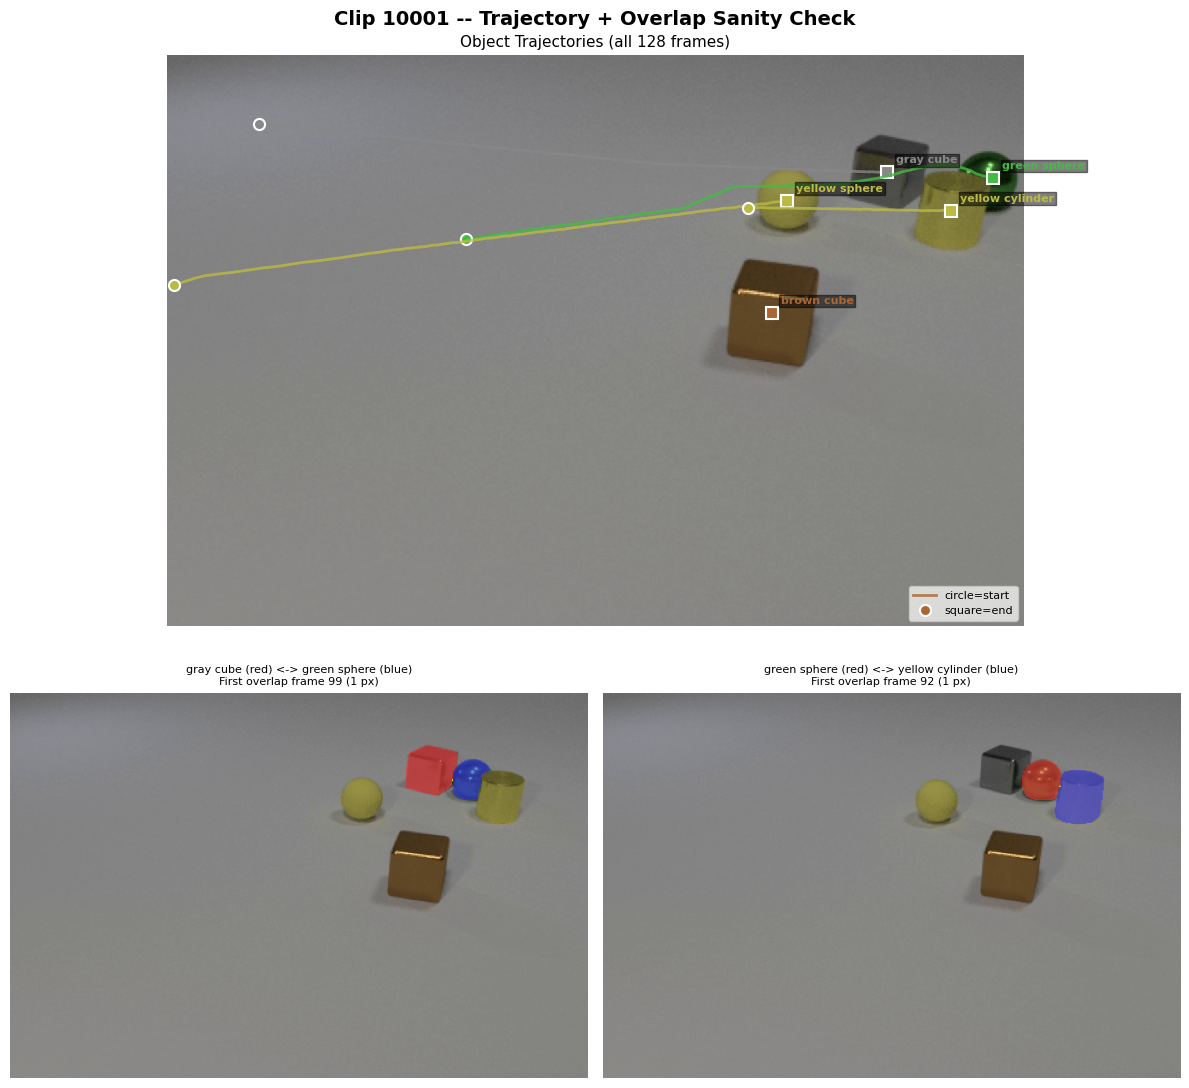

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/02a_sanity_combined_clip10001.jpg


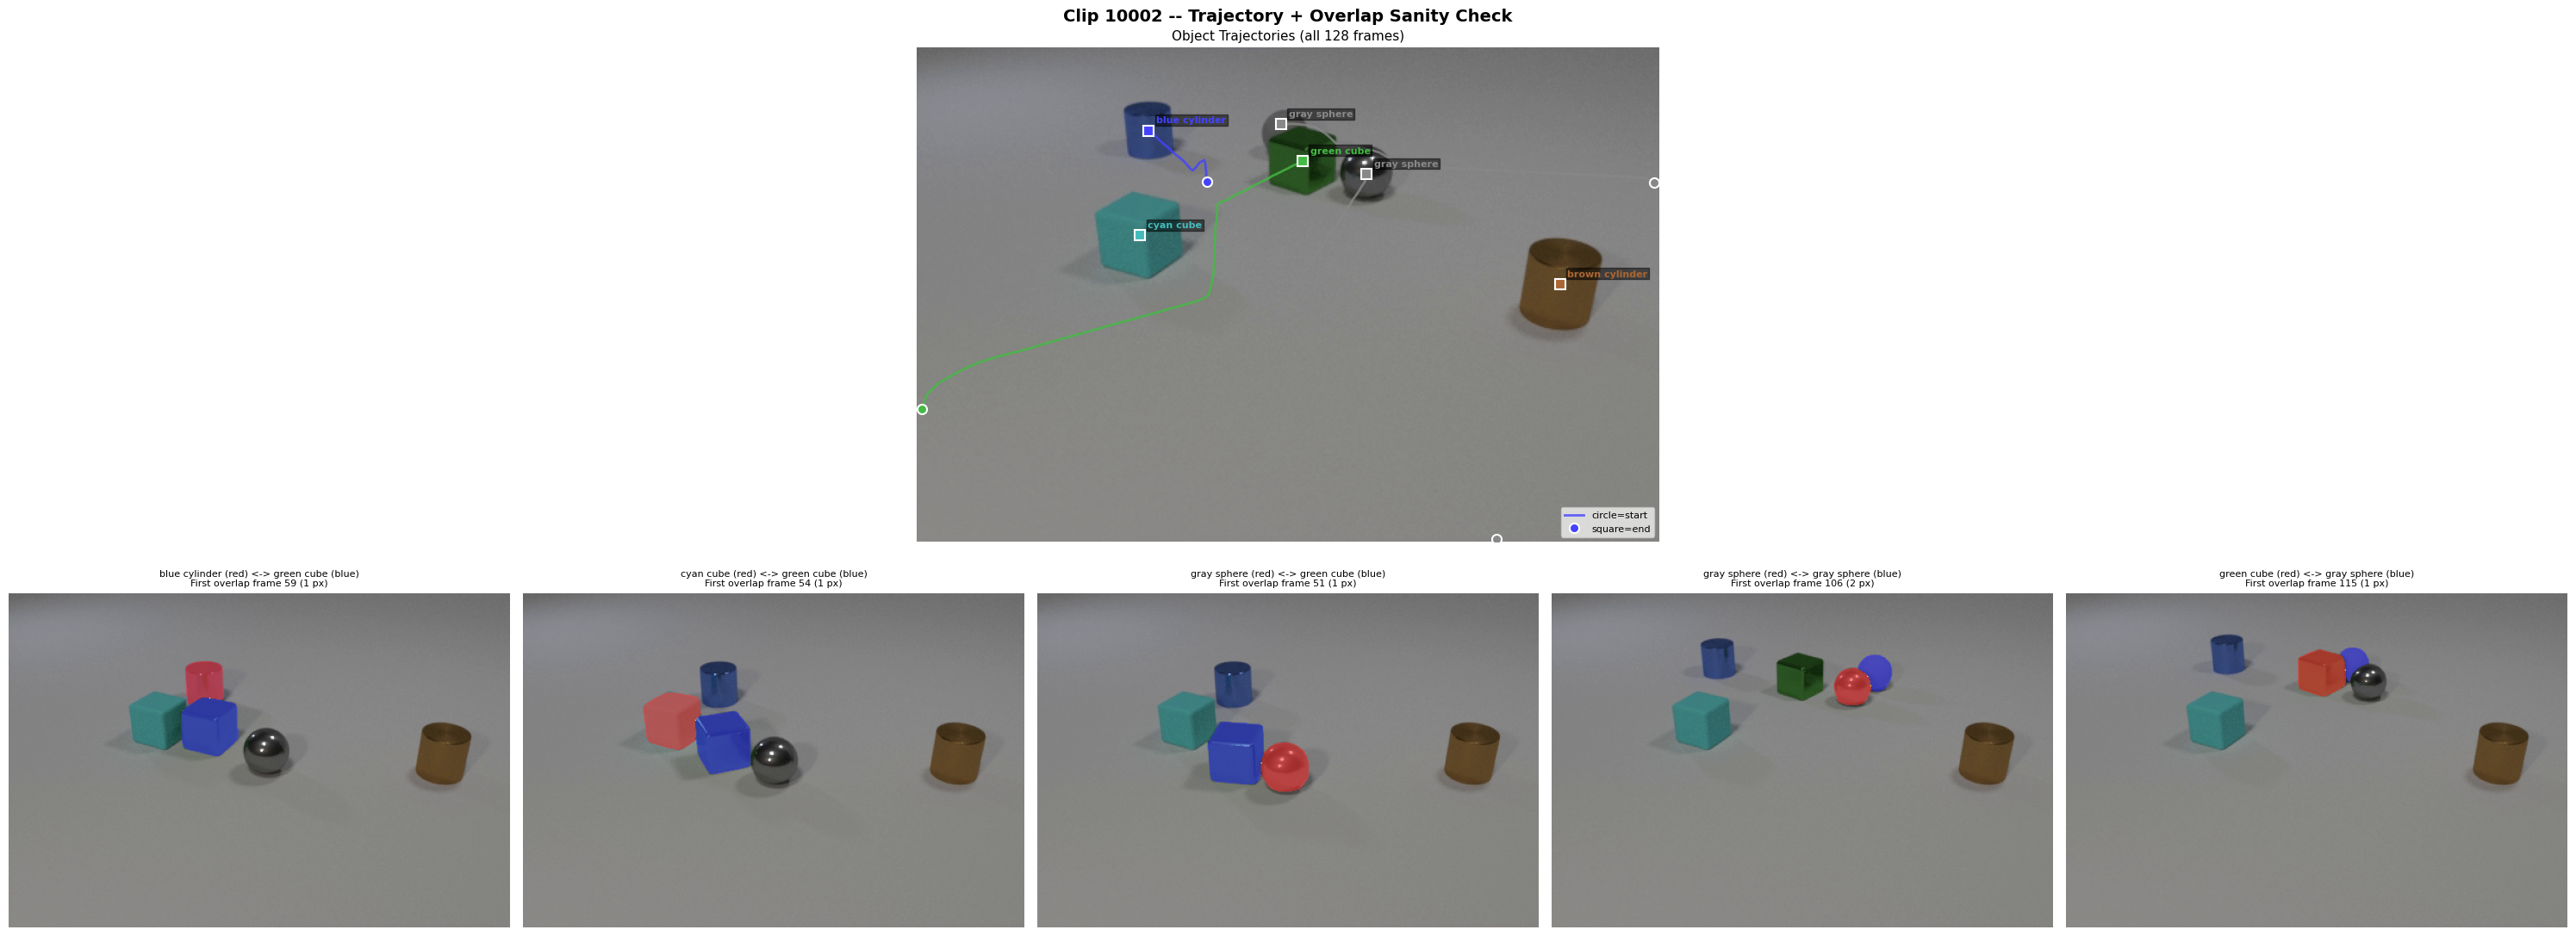

Saved -> /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/figures/02a_sanity_combined_clip10002.jpg

Cell 8 complete.


In [19]:
# ── Cell 8 — Combined Sanity Check Visualization ──────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import os

# CLEVRER color map for trajectory plotting
CLEVRER_COLORS = {
    'red'    : '#FF4444',
    'green'  : '#44BB44',
    'gray'   : '#888888',
    'brown'  : '#AA6633',
    'blue'   : '#4444FF',
    'cyan'   : '#44BBBB',
    'purple' : '#AA44AA',
    'yellow' : '#BBBB44'
}

for vid_id in SELECTED_IDS[:2]:
    masks_dict = sam2_results[vid_id]
    clip_path  = os.path.join(CLIPS_DIR, f"video_{vid_id:05d}.mp4")

    # ── Load last frame as background ──────────────────────────────────────
    frames_rgb  = extract_all_frames(clip_path)
    last_frame  = frames_rgb[127]
    first_frame = frames_rgb[0]

    obj_keys    = list(masks_dict.keys())
    overlaps    = compute_overlap_pairs(masks_dict)
    n_overlaps  = len(overlaps)

    # ── Figure layout: 2 rows ──────────────────────────────────────────────
    # Row 1: trajectory plot (full width)
    # Row 2: one panel per overlap pair
    n_cols = max(n_overlaps, 1)
    fig    = plt.figure(figsize=(6 * n_cols, 12))
    fig.suptitle(f"Clip {vid_id} -- Trajectory + Overlap Sanity Check",
                 fontsize=14, fontweight='bold')

    # ── Row 1: Trajectory plot ─────────────────────────────────────────────
    ax_traj = fig.add_subplot(2, 1, 1)
    ax_traj.imshow(last_frame)
    ax_traj.set_title("Object Trajectories (all 128 frames)", fontsize=11)

    for obj_key, mask_array in masks_dict.items():
        color, material, shape = obj_key
        centroids = compute_centroids_per_frame(mask_array)
        areas     = compute_areas_per_frame(mask_array)

        # Only plot visible frames
        valid     = np.where(areas > 0)[0]
        if len(valid) == 0:
            continue

        cx_vals = centroids[valid, 0]
        cy_vals = centroids[valid, 1]
        c_hex   = CLEVRER_COLORS.get(color, '#FFFFFF')

        # Plot trajectory line
        ax_traj.plot(cx_vals, cy_vals, '-', color=c_hex,
                     linewidth=2, alpha=0.8)

        # Mark start and end
        ax_traj.plot(cx_vals[0],  cy_vals[0],  'o', color=c_hex,
                     markersize=8, markeredgecolor='white', markeredgewidth=1.5)
        ax_traj.plot(cx_vals[-1], cy_vals[-1], 's', color=c_hex,
                     markersize=8, markeredgecolor='white', markeredgewidth=1.5)

        # Label at end point
        ax_traj.text(cx_vals[-1] + 5, cy_vals[-1] - 5,
                     f"{color} {shape}",
                     color=c_hex, fontsize=8, fontweight='bold',
                     bbox=dict(facecolor='black', alpha=0.5, pad=1))

    ax_traj.legend(['circle=start', 'square=end'], loc='lower right',
                   fontsize=8, framealpha=0.7)
    ax_traj.axis('off')

    # ── Row 2: Overlap panels ──────────────────────────────────────────────
    for col, ov in enumerate(overlaps):
        ax = fig.add_subplot(2, n_cols, n_cols + col + 1)

        key_a    = ov['obj_a']
        key_b    = ov['obj_b']
        fid      = ov['first_overlap_frame']
        frame    = frames_rgb[fid].copy()

        mask_a   = masks_dict[key_a][fid]
        mask_b   = masks_dict[key_b][fid]

        # Overlay mask A in red, mask B in blue
        overlay              = frame.copy()
        overlay[mask_a]      = (overlay[mask_a] * 0.4 +
                                np.array([255, 60, 60]) * 0.6).astype(np.uint8)
        overlay[mask_b]      = (overlay[mask_b] * 0.4 +
                                np.array([60, 60, 255]) * 0.6).astype(np.uint8)

        # Highlight intersection in yellow
        intersection         = mask_a & mask_b
        overlay[intersection] = [255, 255, 0]

        ax.imshow(overlay)

        a_label = f"{key_a[0]} {key_a[2]}"
        b_label = f"{key_b[0]} {key_b[2]}"
        ax.set_title(f"{a_label} (red) <-> {b_label} (blue)\n"
                     f"First overlap frame {fid} "
                     f"({ov['overlap_pixel_count']} px)",
                     fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    fig_path = os.path.join(FIGURES_DIR,
                f"02a_sanity_combined_clip{vid_id}.jpg")
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved -> {fig_path}")

print("\nCell 8 complete.")

---
## Cell 9 — Drive Space Check + Completion Summary

In [20]:
# ── Cell 9 — Drive Space Check + Completion Summary ───────────────────────
import os

# ── Check .npz files saved ─────────────────────────────────────────────────
npz_files  = [f for f in os.listdir(OUT_SAM2)
               if f.startswith('stage1_sam2_') and f.endswith('.npz')]
total_bytes = sum(
    os.path.getsize(os.path.join(OUT_SAM2, f))
    for f in npz_files
)

print("── Stage 1 SAM 2 Output Summary ──────────────────────────────")
print(f"  Clips processed : {len(npz_files)}")
print(f"  Files saved to  : {OUT_SAM2}")
print(f"  Total size      : {total_bytes / 1e6:.2f} MB")
print(f"  Avg per clip    : {total_bytes / max(len(npz_files),1) / 1e6:.2f} MB")
print()
print("── Files on Drive ────────────────────────────────────────────")
for f in sorted(npz_files):
    fpath = os.path.join(OUT_SAM2, f)
    print(f"  {f}  ({os.path.getsize(fpath)/1e3:.1f} KB)")
print()
print("Notebook 02a complete. Proceed to 02b_depth.ipynb.")

── Stage 1 SAM 2 Output Summary ──────────────────────────────
  Clips processed : 70
  Files saved to  : /content/drive/MyDrive/NEU - MS CS/4_SEM (Jan 2026)/CV/Projects/final_project/outputs/stage1_sam2
  Total size      : 0.99 MB
  Avg per clip    : 0.01 MB

── Files on Drive ────────────────────────────────────────────
  stage1_sam2_10001.npz  (15.0 KB)
  stage1_sam2_10002.npz  (16.5 KB)
  stage1_sam2_10003.npz  (12.0 KB)
  stage1_sam2_10004.npz  (12.2 KB)
  stage1_sam2_10005.npz  (14.7 KB)
  stage1_sam2_10006.npz  (8.8 KB)
  stage1_sam2_10007.npz  (14.7 KB)
  stage1_sam2_10008.npz  (15.7 KB)
  stage1_sam2_10009.npz  (12.6 KB)
  stage1_sam2_10010.npz  (14.2 KB)
  stage1_sam2_10011.npz  (18.1 KB)
  stage1_sam2_10012.npz  (13.9 KB)
  stage1_sam2_10013.npz  (12.2 KB)
  stage1_sam2_10014.npz  (12.4 KB)
  stage1_sam2_10015.npz  (17.9 KB)
  stage1_sam2_10016.npz  (15.0 KB)
  stage1_sam2_10017.npz  (14.9 KB)
  stage1_sam2_10018.npz  (14.1 KB)
  stage1_sam2_10019.npz  (14.9 KB)
  stage1_sam

---